In [54]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt 

In [55]:
def payments(yen_0, yen_t , baht_0, baht_t):
    alpha_yen = max(0, (yen_t-yen_0)/yen_t)
    alpha_baht= min(1, 5*(baht_0-baht_t)/baht_t) 
    alpha = alpha_yen + alpha_baht
    return 53 *(1-0.03-alpha)


In [56]:
yen_0 = 122
baht_0= 25.884
yen_t = np.arange(100,151,5)
baht_t = np.arange(15,36,1)


table = pd.DataFrame(index=baht_t , columns=yen_t)

for b in baht_t:
    for y in yen_t:
        table.loc[b,y] = payments(yen_0,y, baht_0, b)

table.tail()

,100,105,110,115,120,125,130,135,140,145,150
31,95.143548,95.143548,95.143548,95.143548,95.143548,93.871548,91.88201,90.039845,88.329263,86.736652,85.250215
32,102.058125,102.058125,102.058125,102.058125,102.058125,100.786125,98.796587,96.954421,95.243839,93.651228,92.164792
33,108.553636,108.553636,108.553636,108.553636,108.553636,107.281636,105.292098,103.449933,101.739351,100.14674,98.660303
34,114.667059,114.667059,114.667059,114.667059,114.667059,113.395059,111.40552,109.563355,107.852773,106.260162,104.773725
35,120.431143,120.431143,120.431143,120.431143,120.431143,119.159143,117.169604,115.327439,113.616857,112.024246,110.53781


Text(0.5, 0.5, 'baht')

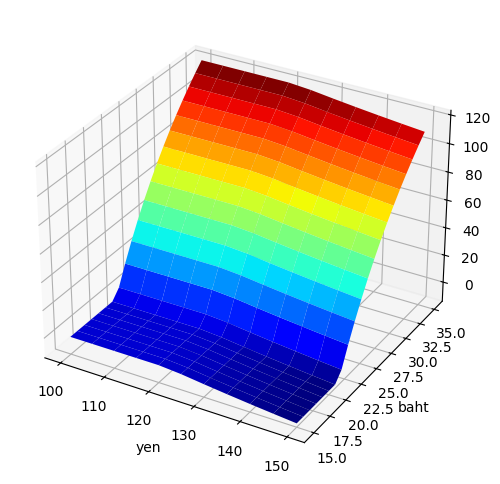

In [57]:
x,y=np.meshgrid(table.columns.astype(float), table.index.astype(float))
z=table.values.astype(float)

fig=plt.figure(figsize=(10,6))
ax=fig.add_subplot(111,projection='3d')

ax.plot_surface(x,y,z , cmap='jet')
ax.set_xlabel("yen")
ax.set_ylabel('baht')

In [58]:
# suppose baht_t = 44.95, yen_t = 123.17 then,,
yen_0 = 122
baht_0= 25.884
baht_t = 44.95
yen_t = 123.17

print(f'payments: {payments(yen_0,yen_t,baht_0, baht_t)}')
print(f'loss:  {53 - payments(yen_0,yen_t,baht_0, baht_t)}')

payments: 163.30899664796738
loss:  -110.30899664796738


### Present value

In [59]:
np.random.seed(42)

def simulate_fx(y0, b0, rd, ry, rb, sigmaY, sigmaB, rho, T, M):
    x1 = np.random.normal(loc=0.0, scale=1.0, size=M)
    x2 = np.random.normal(loc=0.0, scale=1.0, size=M)
    eps1 = x1
    eps2 = rho*x1 + np.sqrt(1-rho**2)*x2 

    inv_yt = (1/y0) * np.exp((rd-ry-0.5*sigmaY**2)*T + sigmaY*eps1*np.sqrt(T))
    inv_bt = (1/b0) * np.exp((rd-rb-0.5*sigmaB**2)*T + sigmaB*eps2*np.sqrt(T))

    yt = 1/inv_yt
    bt = 1/inv_bt 
    return yt, bt 

In [60]:
def alpha_fx(y0, yt, b0, bt , multiplier):
    alpha_y = np.maximum(0, (yt-y0)/yt)
    alpha_b = np.minimum(multiplier*(b0-bt)/bt, 1)
    return alpha_y + alpha_b 

In [61]:
def pv_fx(alpha , notional , rd , T):
    payments = notional*(1-0.03-alpha)
    pv = np.mean(payments)*np.exp(-rd*T)
    return pv , payments 

In [62]:
y0 = 122
b0= 25.884
rho = 0.2

rd = 0.03
ry = 0.01
rb = 0.13

T = 1.0 
M= 100000
multiplier = 5.0 
notional = 53

In [63]:
sigma_y = np.array([0.01, 0.05, 0.10, 0.20, 0.3, 0.5, 0.6])
sigma_b =  np.array([0.01, 0.05, 0.10, 0.20, 0.3, 0.5, 0.6])

In [64]:
table = pd.DataFrame(index = sigma_y , columns=sigma_b)
for y in sigma_y:
    for b in sigma_b:
        yt , bt = simulate_fx(y0, b0, rd, ry, rb, y, b, rho, T, M)
        alpha = alpha_fx(y0, yt, b0, bt , multiplier)
        pv, payments  = pv_fx(alpha ,notional , rd , T)
        table.loc[y,b] = np.round(pv, 2)

table.head(10)

,0.01,0.05,0.10,0.20,0.30,0.50,0.60
0.01,74.36,74.36,74.46,76.15,82.3,97.83,107.12
0.05,73.76,73.78,73.73,75.59,81.04,97.36,106.82
0.10,72.77,72.83,72.74,74.72,80.21,96.0,105.7
0.20,70.71,70.73,70.74,72.58,78.16,93.91,103.5
0.30,68.69,68.82,68.7,70.57,76.06,92.05,101.05
0.50,64.68,64.6,64.63,66.39,72.04,88.59,96.91
0.60,62.61,62.68,62.65,64.58,69.84,86.08,94.89


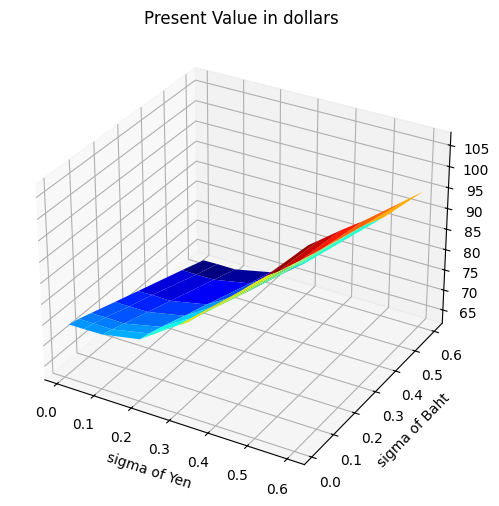

In [65]:
x,y = np.meshgrid(table.index.astype(float), table.columns.astype(float))
z = table.values.astype(float)

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(x,y,z, cmap="jet")

ax.set_xlabel("sigma of Yen")
ax.set_ylabel("sigma of Baht")
plt.title("Present Value in dollars")
plt.show()


In [66]:
multiplier = np.array([3,4,5,6])
results = []

for m in multiplier:
     yt , bt = simulate_fx(y0, b0, rd, ry, rb, 0.1, 0.1, rho, T, M)
     alpha = alpha_fx(y0, yt, b0, bt , m)
     pv, payments= pv_fx(alpha, notional, rd, T)
     results.append(pv)

In [67]:
pd.DataFrame({
    'sigma_y' : 0.1, 
    'sigma_b' : 0.1,
    'multiplier': multiplier,
    'value' : np.round(results,2)
}).set_index(['sigma_y', 'sigma_b', 'multiplier'])

value
sigma_y sigma_b multiplier       
0.1     0.1     3           63.00
                4           67.96
                5           72.84
                6           77.71